# Evaluation
## Search Evaluation
### Ground truth dataset
In order to evaluate the performance of the search function, we generate a synthetic dataset that models how we want the function to behave. It is generated through a reverse-engineering process: for every document in a sample, an LLM is prompted to come up with realistic queries that could be asked about the content found in that document. The output of this process is a set of query-document pairs that is referred to as the ground truth.

Later in the evaluation process, we will measure how well the search functionality peforms at retrieving the ground truth document given the associated query as input.

In [1]:
from wikifin_rag.factories import dict_factory
from wikifin_rag.db_client import DocumentsDBClient
from pydantic import BaseModel

In [2]:
def load_wikifin_data(factory=dict_factory):
    db_client = DocumentsDBClient()

    with db_client.get_db_connection() as con:
        con.row_factory = factory

        cur = con.execute("""
            SELECT
                c.document_id || '_' || c.chunk_id AS id,
                d.title,
                d.section,
                c.content,
                c.embedding,
                d.source_url
            FROM chunks c
            JOIN documents d
            ON c.document_id = d.id
            WHERE d.language = 'nl';
        """)

    return cur.fetchall()

In [3]:
documents = load_wikifin_data()

In [4]:
class Questions(BaseModel):
    questions: list[str]

In [5]:
data_gen_instructions = """
You emulate a student or young professional who has questions about personal finance.
Formulate {} questions this person might ask based on a document passage.
The passage should contain the answer to the questions, and the questions should be complete and not too short.
If possible, use as fewer words as possible from the record.

The output should resemble how people ask questions
on the internet. Not too formal, not too short, not too long.
""".strip()

In [6]:
from dotenv import load_dotenv
from openai import OpenAI
from wikifin_rag.evaluation_utils import llm_structured_retry

In [7]:
load_dotenv(override=True)
openai_client = OpenAI()

In [8]:
def generate_document_ground_truth(doc, n=5):
    """
    Generates n questions about the input document's content.
    """
    user_prompt = doc['content']

    out, usage = llm_structured_retry(
        openai_client,
        data_gen_instructions.format(n),
        user_prompt,
        Questions
    )

    results = []

    for q in out.questions:
        results.append({
            "question": q,
            "document": doc["id"]
        })

    return results, usage

In [9]:
from concurrent.futures import ThreadPoolExecutor
from wikifin_rag.evaluation_utils import map_progress
import pandas as pd
from wikifin_rag.config import PROJECT_ROOT
from pathlib import Path
import numpy as np
import os

In [10]:
def generate_corpus_ground_truth(documents, n=5, file_path=PROJECT_ROOT / "data" / "evals" / "ground_truth.csv"):
    """
    Creates a dataset of n questions per document in the input corpus.
    Output is saved to a CSV file.
    """
    with ThreadPoolExecutor(max_workers=6) as pool:
        results = map_progress(pool, documents, lambda doc: generate_document_ground_truth(doc, n=n))

    ground_truth = []
    usages = []

    for records, usage in results:
        ground_truth.extend(records)
        usages.append(usage)

    file_path = Path(file_path)
    file_path.parent.mkdir(parents=True, exist_ok=True)
    df_ground_truth = pd.DataFrame(ground_truth)
    df_ground_truth.to_csv(file_path, index=False)


In [11]:
# number of documents to use
n_documents = 500

# number of question to generate per document
n_questions = 5

# file path for the generated ground truth dataset
ground_truth_file_path = PROJECT_ROOT / "data" / "evals" / "retrieval_ground_truth.csv"

In [12]:
# TODO: change to True to force a ground truth data refresh
refresh_ground_truth = False

In [13]:
if refresh_ground_truth or not os.path.exists(ground_truth_file_path):
    # use a random sample of documents to generate the ground truth dataset
    sample = np.random.choice(documents, size=n_documents, replace=False)

    generate_corpus_ground_truth(documents=sample, n=n_questions, file_path=ground_truth_file_path)

In [14]:
eval_split = .25

In [15]:
# split dataset for optimization and evaluation
df_ground_truth = pd.read_csv(ground_truth_file_path)
df_ground_truth.reset_index(names="index", inplace=True)
df_ground_truth_eval = df_ground_truth.sample(frac=eval_split, random_state=1)
df_ground_truth_optim = df_ground_truth.loc[~df_ground_truth.index.isin(df_ground_truth_eval.index)]

In [16]:
ground_truth = df_ground_truth_optim.to_dict(orient="records")

### Search Parameter Tuning
#### Text Search
The text search function returns the documents that have the highest amount of overlap with the search query. Overlap corresponds to the frequency with which individual query terms appear in a document. The more often the query terms appear in the document, the higher the document is ranked by the search function.

Occurences of overlapping terms are weighted differently depending on where they appear in the document. A change in the weighting scheme will therefore impact the document ranking for a given search query, and potentially produce a different result set.

We optimize the retrieval system based on the mean reciprocal rank (MRR) by adjusting the boosting weights. Our goal is to identify the set of weights that yields the highest MRR on the previously generated ground truth dataset. MRR considers how highly the golden truth document is ranked by the search function for each query in the dataset.

In [17]:
from wikifin_rag.evaluation_utils import evaluate
from wikifin_rag.search_utils import build_text_index, text_search
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import pickle

In [18]:
ts_index = build_text_index(documents=documents)

In [19]:
def ts_objective(params):
    metrics = evaluate(
        ground_truth=ground_truth,
        search_function=lambda query: text_search(query=query, index=ts_index, boost_dict=params)
    )

    return {
        'loss': -round(metrics['mrr'], 4),
        'status': STATUS_OK,
        'params': params,
        'metrics': metrics
    }

In [20]:
n_evals = 10

In [21]:
ts_trials_file_path = PROJECT_ROOT / "data" / "evals" / "ts_trials.pkl"

In [22]:
# TODO: change to True to force a ground truth data refresh
refresh_search_optimization = False

In [23]:
ts_search_space = {
    "title": hp.uniform("title", 0, 10),
    "description": hp.uniform("description", 0, 10),
    "section": hp.uniform("section", 0, 10),
    "content": hp.uniform("content", 0, 10)
}

In [24]:
if refresh_search_optimization or not os.path.exists(ts_trials_file_path):
    ts_trials_file_path.parent.mkdir(parents=True, exist_ok=True)
    
    trials = Trials()

    best_params = fmin(
        fn=ts_objective,
        space=ts_search_space,
        algo=tpe.suggest,
        max_evals=n_evals,
        trials=trials
    )

    trials_data = [{
        'id': trial['tid'],
        'mrr': trial['result']['metrics']['mrr'],
        'hit_rate': trial['result']['metrics']['hit_rate'],
        'params': trial['result']['params'],
    } for trial in trials.trials]
    
    with open(ts_trials_file_path, "wb") as file:
        pickle.dump((best_params, trials_data), file)

In [25]:
with open(ts_trials_file_path, "rb") as file:
    ts_params, ts_trials_data = pickle.load(file)

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
ts_trials_data_df = pd.DataFrame(ts_trials_data)

In [28]:
ts_trials_data_df_long = ts_trials_data_df.melt(
    id_vars=ts_trials_data_df.drop(["mrr", "hit_rate"], axis=1).columns,
    value_vars=["mrr", "hit_rate"],
    var_name="metric"
)

In [29]:
sns.set_style("darkgrid", {"axes.facecolor": ".9"})
sns.set_context("notebook")

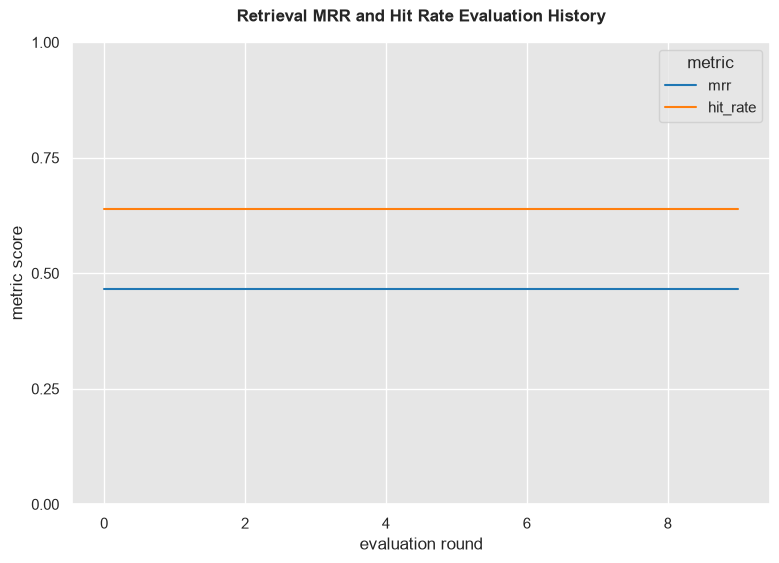

In [30]:
plt.figure(figsize=(9, 6))
plt.title("Retrieval MRR and Hit Rate Evaluation History", fontweight="bold", pad=15)
plt.xlabel("evaluation round")
plt.ylabel("metric score")

g = sns.lineplot(
    data=ts_trials_data_df_long,
    x="id",
    y="value",
    hue="metric"
)

g.set(ylim=(0, 1), yticks=[0, 0.25, 0.5, 0.75, 1])

plt.show()

In [31]:
ts_best_metrics = max(ts_trials_data, key=lambda d: d['mrr'])
print(f"Text search MRR: {round(ts_best_metrics['mrr'], 4)} | Hit Rate: {round(100 * ts_best_metrics['hit_rate'], 2)}%")

Text search MRR: 0.4651 | Hit Rate: 63.89%


#### Vector Search
Instead of relying on term overlap, vector search measures similarity between texts based on their embeddings. Embedding vectors capture the semantic meaning of text, thus allowing for more nuanced comparisons that are independent of word choice.

The embedding process converts texts into numerical vectors of the same length. From there, assessing the similarity between documents consists in measuring the distance between the associated embedding vectors. The shorter the distance between the vectors, the more semantically similar to documents are.

Similarly to text search, the vector-based retrieval function is parametrized and we optimize the parameters following the same process as above.

In [32]:
from wikifin_rag.search_utils import build_vector_index, vector_search
from wikifin_rag.factories import embedding_factory
from wikifin_rag.embedder import Embedder
from hyperopt.pyll import scope

In [33]:
documents = load_wikifin_data(embedding_factory)
embeddings = [doc.pop('embedding') for doc in documents]

In [34]:
embedder = Embedder()

In [35]:
def vs_objective(params):
    vs_index = build_vector_index(vectors=embeddings, documents=documents, **params)

    metrics = evaluate(
        ground_truth=ground_truth,
        search_function=lambda query: vector_search(index=vs_index, query=query, embedder=embedder)
    )

    return {
        'loss': -round(metrics['mrr'], 4),
        'status': STATUS_OK,
        'params': params,
        'metrics': metrics
    }

In [36]:
vs_search_space = hp.pchoice(
    "mode",
    [
        # HNSW
        (0.8, {
            "mode": "hnsw",
            "m": hp.choice("m", [8, 12, 16, 24, 32]),
            "ef_construction": hp.choice(
                "ef_construction",
                [50, 100, 200, 400],
            ),
            "ef_search": hp.choice(
                "ef_search",
                [10, 20, 40, 80, 160, 320],
            )
        }),

        # LSH
        (0.1, {
            "mode": "lsh",
            "n_tables": scope.int(hp.quniform("lsh_n_tables", 2, 32, 1)),
            "hash_size": scope.int(hp.quniform("lsh_hash_size", 8, 24, 1)),
            "n_probe": scope.int(hp.quniform("lsh_n_probe", 0, 2, 1)),
        }),

        # IVF
        (0.1, {
            "mode": "ivf",
            "n_clusters": hp.choice(
                "n_clusters",
                [None, 32, 64, 128, 256, 512]
            ),
            "n_probe_clusters": scope.int(hp.quniform(
                "n_probe_clusters", 1, 32, 1
            )),
        }),
    ]
)

In [37]:
vs_trials_file_path = PROJECT_ROOT / "data" / "evals" / "vs_trials.pkl"

In [38]:
if refresh_search_optimization or not os.path.exists(vs_trials_file_path):
    vs_trials_file_path.parent.mkdir(parents=True, exist_ok=True)
    
    trials = Trials()

    best_params = fmin(
        fn=vs_objective,
        space=vs_search_space,
        algo=tpe.suggest,
        max_evals=n_evals,
        trials=trials
    )

    trials_data = [{
        'id': trial['tid'],
        'mrr': trial['result']['metrics']['mrr'],
        'hit_rate': trial['result']['metrics']['hit_rate'],
        'params': trial['result']['params']
    } for trial in trials.trials]

    with open(vs_trials_file_path, "wb") as file:
        pickle.dump((best_params, trials_data), file)

In [39]:
with open(vs_trials_file_path, "rb") as file:
    _, vs_trials_data = pickle.load(file)

In [40]:
vs_trials_data_df = pd.DataFrame(vs_trials_data)

In [41]:
vs_trials_data_df_long = vs_trials_data_df.melt(
    id_vars=vs_trials_data_df.drop(["mrr", "hit_rate"], axis=1).columns,
    value_vars=["mrr", "hit_rate"],
    var_name="metric"
)

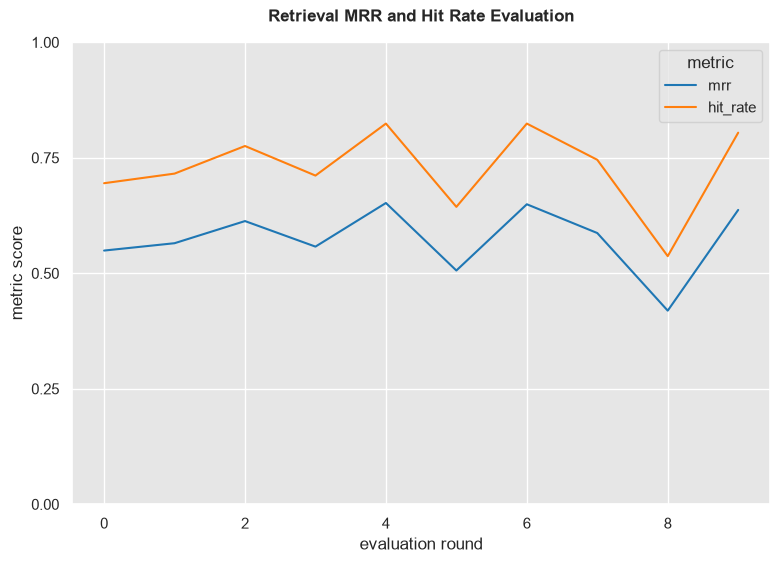

In [42]:
plt.figure(figsize=(9, 6))
plt.title("Retrieval MRR and Hit Rate Evaluation", fontweight="bold", pad=15)
plt.xlabel("evaluation round")
plt.ylabel("metric score")

g = sns.lineplot(
    data=vs_trials_data_df_long,
    x="id",
    y="value",
    hue="metric"
)

g.set(ylim=(0, 1), yticks=[0, 0.25, 0.5, 0.75, 1])

plt.show()

In [43]:
vs_best_metrics = max(vs_trials_data, key=lambda d: d['mrr'])
print(f"Vector search MRR: {round(vs_best_metrics['mrr'], 4)} | Hit Rate: {round(100 * vs_best_metrics['hit_rate'], 2)}%")

Vector search MRR: 0.6521 | Hit Rate: 82.4%


### Search Testing
Evaluate and compare the optimized text and search functions, as well a hybrid search combining the two previous approaches through reranking.

In [44]:
from wikifin_rag.search_utils import rrf_hybrid_search

In [45]:
ts_index = build_text_index(documents)

In [46]:
def optimized_text_search(query, num_results=5):
    return text_search(query=query, index=ts_index, num_results=num_results, boost_dict=ts_params)

In [47]:
with open(PROJECT_ROOT / "data" / "evals" / "ts_index_params.pkl", "wb") as file:
    pickle.dump(ts_params, file)

In [48]:
vs_best_params = max(vs_trials_data, key=lambda d: d['mrr'])['params']
vs_index = build_vector_index(embeddings, documents, **vs_best_params)

In [49]:
def optimized_vector_search(query, num_results=5):
    return vector_search(query=query, index=vs_index, embedder=embedder, num_results=num_results)

In [50]:
with open(PROJECT_ROOT / "data" / "evals" / "vs_index_params.pkl", "wb") as file:
    pickle.dump(vs_best_params, file)

In [51]:
def hybrid_search(query, num_results=5):
    ts_results = optimized_text_search(query=query, num_results=num_results)
    vs_results = optimized_vector_search(query=query, num_results=num_results)

    return rrf_hybrid_search([ts_results, vs_results], num_results=num_results)

In [52]:
hs_metrics = evaluate(ground_truth=ground_truth, search_function=hybrid_search)
print(f"Hybrid search MRR: {round(hs_metrics['mrr'], 4)} | Hit Rate: {round(100 * hs_metrics['hit_rate'], 2)}%")

  0%|          | 0/1875 [00:00<?, ?it/s]

Hybrid search MRR: 0.6218 | Hit Rate: 80.53%


In [53]:
evaluation_rounds = 10
evaluation_sample_size = 200

In [54]:
search_functions = [optimized_text_search, optimized_vector_search, hybrid_search]

In [55]:
eval_results = []

for i in range(evaluation_rounds):
    sample_data = df_ground_truth_eval.sample(n=evaluation_sample_size, random_state=i).to_dict(orient='records')

    for search_function in search_functions:
        fold_metrics = evaluate(sample_data, search_function=search_function)
        fold_metrics['id'] = i
        fold_metrics['function'] = search_function.__name__

        eval_results.append(fold_metrics)

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [56]:
metrics_df = pd.DataFrame(eval_results)

In [57]:
metrics_df_long = metrics_df.melt(
    id_vars=["id", "function"],
    value_vars=["mrr", "hit_rate"],
    var_name="metric"
)

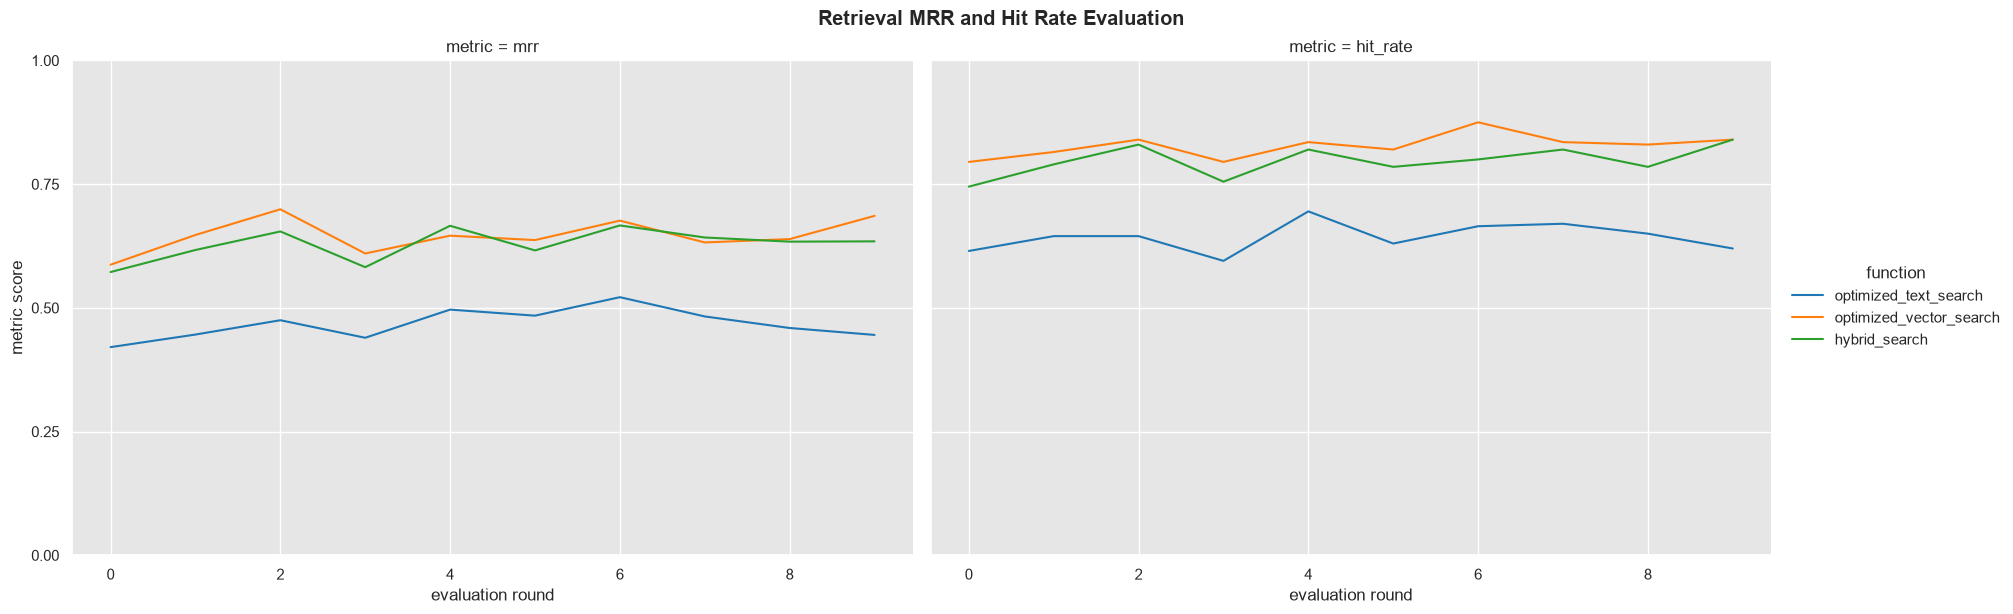

In [58]:
metrics_df_long = metrics_df.melt(
    id_vars=["id", "function"],
    value_vars=["mrr", "hit_rate"],
    var_name="metric"
)

g = sns.relplot(
    data=metrics_df_long,
    x="id",
    y="value",
    col="metric",
    hue="function",
    kind="line",
    height=6,
    aspect=1.5
)

g.set(ylim=(0, 1), yticks=[0, 0.25, 0.5, 0.75, 1])


g.figure.suptitle(
    "Retrieval MRR and Hit Rate Evaluation",
    fontweight="bold",
    y=1.02
)

g.set_axis_labels("evaluation round", "metric score")

plt.show()

## RAG Evaluation
### Ground truth dataset

In [59]:
from wikifin_rag.rag_helper import RAGBase
from wikifin_rag.evaluation_utils import calculate_total_cost

In [60]:
doc_idx = {}

for doc in documents:
    doc_idx[doc["id"]] = doc

In [61]:
assistant = RAGBase(
    search_function=hybrid_search,
    llm_client=openai_client
)

In [62]:
def generate_rag_answer(rec):
    question = rec["question"]
    doc_id = rec["document"]
    original_doc = doc_idx[doc_id]

    llm_answer = assistant.rag(question)
    content = original_doc["content"]

    result = {
        "question": question,
        "answer_llm": llm_answer,
        "content": content,
        "document": doc_id,
    }

    return result

In [ ]:
# number of documents to use
n_samples = 200

# file path for the generated ground truth dataset
rag_answers_path = PROJECT_ROOT / "data" / "evals" / "rag-answers.csv"

In [ ]:
# TODO: change to True to force a ground truth data refresh
refresh_rag_answers = False

In [ ]:
if refresh_rag_answers or not os.path.exists(rag_answers_path):
    assistant.reset_usage()

    rag_answers_path.parent.mkdir(parents=True, exist_ok=True)

    ground_truth_eval = df_ground_truth_eval.sample(n=n_samples).to_dict(orient="records")

    with ThreadPoolExecutor(max_workers=6) as pool:
        answers = map_progress(pool, ground_truth_eval, generate_rag_answer)

    print(f"Data generation cost: ${assistant.total_cost():.4f}")

    df_answers = pd.DataFrame(answers)
    df_answers.to_csv(rag_answers_path, index=False)


In [65]:
from pydantic import Field
from typing import Literal

class AnswerEvaluation(BaseModel):
    reasoning: str = Field(
        description="Reasoning about the quality of the answer."
    )
    score: Literal["good", "bad"] = Field(
        description="'good' if the answer is correct and complete, 'bad' otherwise."
    )

In [66]:
aqa_judge_instructions = """
You are an expert evaluator. You will be given:
1. A question from a user
2. The document chunk based on which the question was formulated (ground truth)
3. An answer to the question generated by an AI assistant

Your task is to decide if the AI answer is complete and
correctly reflects the information found in the document.

Rules:
- The AI answer should NOT quote the document word-for-word
- It should convey the same key information in simple terms
- Extra detail is fine as long as the core answer is correct
- Mark 'bad' only if the AI answer is wrong or misses the key point

Be fair and focus on correctness, not style.
Always provide your reasoning in English.
""".strip()

In [67]:
aqa_judge_prompt = """
Question:
{question}

Document chunk (ground truth):
{document_chunk}

AI Answer:
{answer_llm}
""".strip()

In [68]:
def evaluate_aqa(question, document_chunk, answer_llm, model="gpt-5.4-mini"):
    prompt = aqa_judge_prompt.format(
        question=question,
        document_chunk=document_chunk,
        answer_llm=answer_llm
    )

    result, usage = llm_structured_retry(
        openai_client,
        aqa_judge_instructions,
        prompt,
        AnswerEvaluation,
        model=model,
    )

    return result, usage

In [69]:
def judge_record(rec):
    eval_result, usage = evaluate_aqa(
        question=rec["question"],
        document_chunk=rec["content"],
        answer_llm=rec["answer_llm"]
    )

    result = {
        "question": rec["question"],
        "document": rec["document"],
        "score": eval_result.score,
        "reasoning": eval_result.reasoning,
    }

    return result, usage

In [ ]:
df_rag_answers = pd.read_csv(rag_answers_path)
rag_answers = df_rag_answers.to_dict(orient='records')

In [ ]:
rag_eval_file_path = PROJECT_ROOT / "data" / "evals" / "rag-evals.csv"

In [ ]:
with ThreadPoolExecutor(max_workers=6) as pool:
    results = map_progress(pool, rag_answers, judge_record)

evaluations = []
usages = []

for evaluation, usage in results:
    evaluations.append(evaluation)
    usages.append(usage)

total_cost = calculate_total_cost(usages)

df_eval = pd.DataFrame(evaluations)
df_eval.to_csv(rag_eval_file_path, index=False)

In [71]:
df_eval = pd.read_csv(rag_eval_file_path)

In [72]:
good_count = (df_eval["score"] == "good").sum()
total_count = len(df_eval)
print(f"Good: {good_count}/{total_count} = {good_count/total_count:.2%}")

Good: 169/200 = 84.50%


In [73]:
df_eval[df_eval["score"] == "bad"].head()

,question,document,score,reasoning
5,Welke van de vier manieren past het best bij e...,476a1b9b802a62cc_0,bad,De vraag is welke van de vier manieren het bes...
8,Val ik in een andere categorie als ik wettelij...,ff546a28bfb80d52_0,bad,The document says there is a distinction depen...
13,Wanneer is het slim om extra info te vragen aa...,8edf4c764c612c47_0,bad,De vraag gaat over wanneer het slim is om extr...
28,Waar moet ik op letten als ik online mijn kred...,1acad3488f2dae75_0,bad,De vraag gaat over waar je op moet letten bij ...
38,"Wat betekent ‘lenen’ precies in deze passage, ...",781b2570423db8de_0,bad,The provided ground truth chunk only contains ...


In [74]:
openai_client.close()